
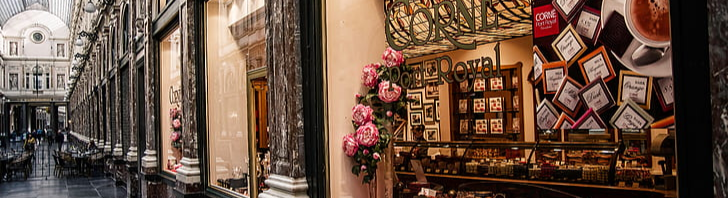

**Customer Segmentation Based on Transaction History: A Case Study of a UK-Based Online Store**


# Loading Data and Initial Analysis

The dataset is available from the UC Irvine Machine Learning Repository: https://archive.ics.uci.edu/dataset/352/online+retail

**Original Description:**

This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

**Feature Details:**

*InvoiceNo*: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.

*StockCode*: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.

*Description*: Product (item) name. Nominal.

*Quantity*: The quantities of each product (item) per transaction. Numeric.

*InvoiceDate*: Invoice Date and time. Numeric, the day and time when each transaction was generated.

*UnitPrice*: Unit price. Numeric, Product price per unit in sterling.

*CustomerID*: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.

*Country*: Country name. Nominal, the name of the country where each customer resides.

In [105]:
pip install ucimlrepo

In [106]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# metadata
print(online_retail.metadata)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [107]:
data = online_retail.data.original

# Why Customer Segmentation Matters
- Every transaction reflects a real human with unique motivations, preferences, and decision-making processes.
- Traditional segmentation often relies on broad categories (e.g., location, frequency), missing deeper behavioral patterns.
- Customers may share hidden traits or needs that aren't immediately obvious but emerge through data analysis.
- Transactional data holds the potential to reveal meaningful, non-obvious groupings beyond surface-level demographics.
- A data-driven approach is essential to uncover these segments and avoid assumptions or generic targeting.
- Identifying nuanced customer segments enables more personalized marketing, better resource allocation, and stronger engagement.
- This project aims to use transactional data to define customer segments as a foundation for strategic marketing decisions.


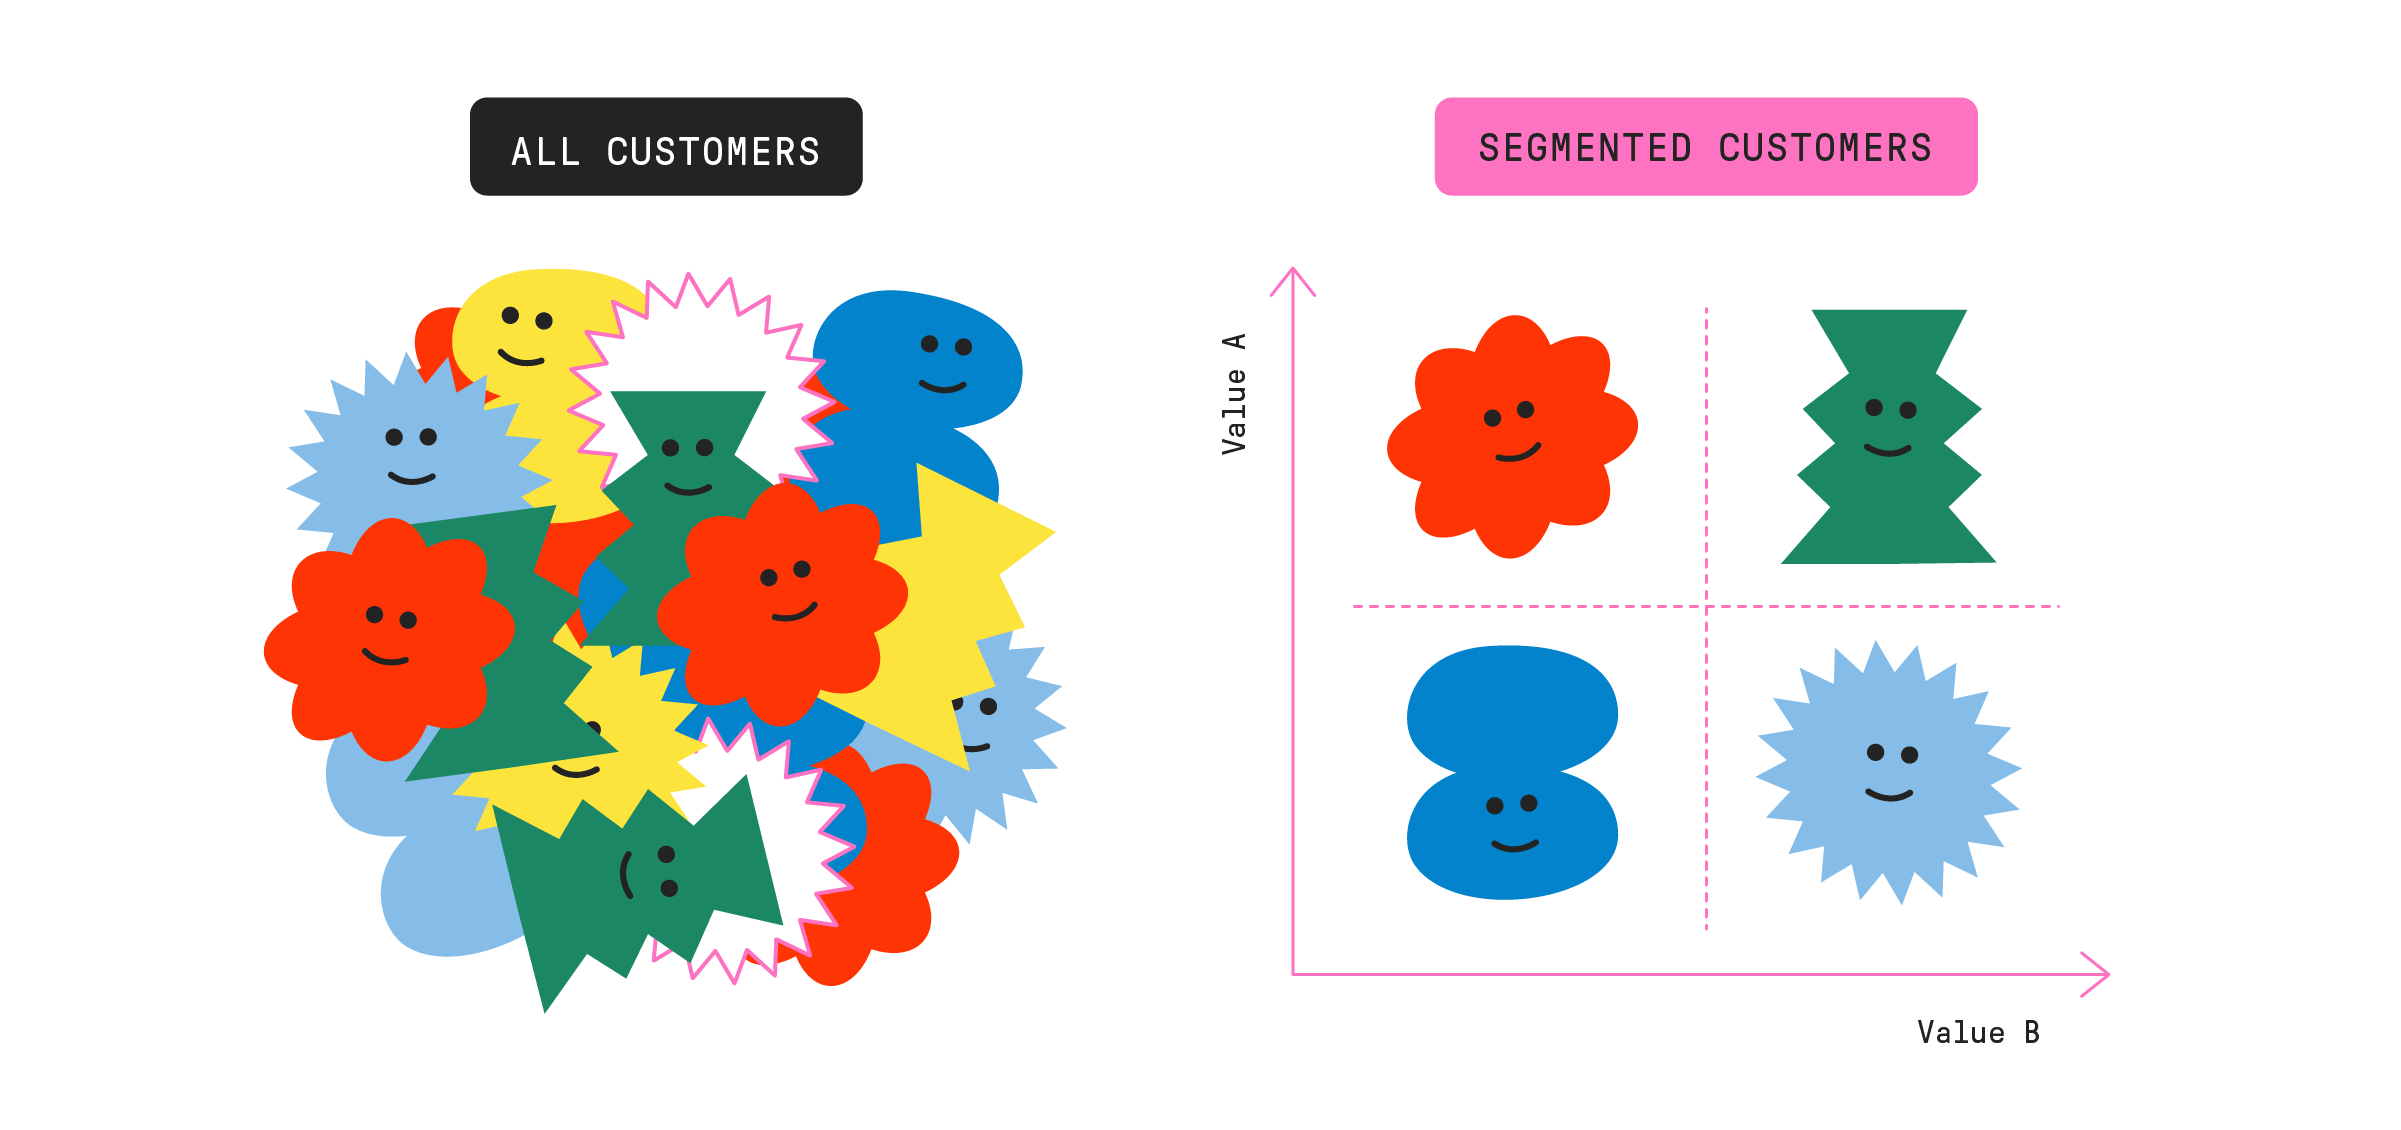

In [108]:
display(data.head(5))
display(data.tail(5))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# Implied Database Schema and Research Focus

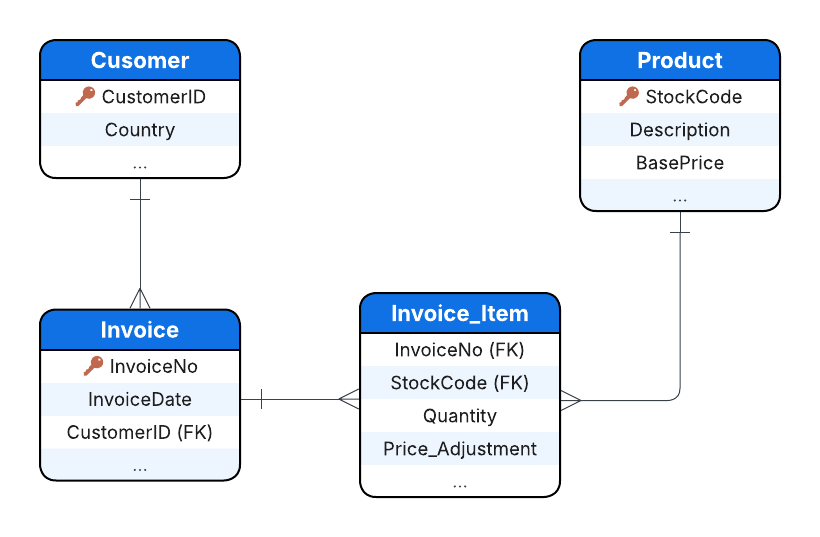

# EDA, Data Cleaning, and Feature Engineering

This phase represented the most time-consuming part of the project. In practice, elements of exploratory data analysis (EDA), data cleaning, and feature engineering were performed iteratively, often revisited as new insights emerged. To manage complexity and ensure reproducibility, sizable blocks of transformations were modularized into 11 staging tables, each representing a distinct step in the data refinement pipeline.

Let me know if you'd like to outline what each staging table does or visualize the pipeline structure.


## Removing items with missing 'CustomerID` field

In [109]:
import pandas as pd
missing_values = data.isnull().sum()
percentage_missing = (missing_values / len(data)) * 100
missing_info = pd.DataFrame({'Missing Values': missing_values, 'Percentage': percentage_missing})
missing_info['Percentage'] = missing_info['Percentage'].map('{:.2f}%'.format)
print(missing_info)

             Missing Values Percentage
InvoiceNo                 0      0.00%
StockCode                 0      0.00%
Description            1454      0.27%
Quantity                  0      0.00%
InvoiceDate               0      0.00%
UnitPrice                 0      0.00%
CustomerID           135080     24.93%
Country                   0      0.00%


In [110]:
data_staging_1 = data.dropna(subset=['CustomerID']).copy()

In [111]:
print(f"Number of unique StockCodes: {data_staging_1['StockCode'].nunique()}")
print(f"Number of unique CustomerIDs: {data_staging_1['CustomerID'].nunique()}")

Number of unique StockCodes: 3684
Number of unique CustomerIDs: 4372


In [112]:
display(data_staging_1.head())
display(data_staging_1.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Cancelled Items
We hypothesize that both the frequency and magnitude (i.e., share of total transaction value) of order cancellations may be relevant factors in determining customer segments. This behavior could reflect customer indecision, dissatisfaction, or operational friction—each potentially segment-defining.

Key Findings
1. Cancelled items alone are insufficient for analysis. To understand what portion of an order was ultimately cancelled, we must identify matching pairs of original orders and their corresponding cancellations.
2. Based on exploratory data analysis, we assume that cancellations are represented as:
    - Voided transactions: The original order entry.
    - Voider transactions: Entries with `InvoiceNo` starting with 'C', matching `UnitPrice` and `StockCode`, but with `Quantity` of opposite sign.
3. Some Voider transactions remain unmatched, meaning they could not be reliably linked to a corresponding Voided transaction. These cases may reflect data inconsistencies or partial cancellations.


In [113]:
data_staging_1['Invoice_Item_ID'] = data_staging_1.reset_index().index

In [114]:
cancellations = data_staging_1[data_staging_1['InvoiceNo'].astype(str).str.startswith('C')].copy()
display(cancellations.head())
display(cancellations.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,141
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,154
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,235
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,236
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,237


,Quantity,UnitPrice,CustomerID,Invoice_Item_ID
count,8905.000000,8905.000000,8905.000000,8905.000000
mean,-30.859966,18.845519,14991.667266,188937.952499
std,1170.154939,444.366043,1706.772357,115227.472147
min,-80995.000000,0.010000,12346.000000,141.000000
25%,-6.000000,1.450000,13510.000000,87723.000000
50%,-2.000000,2.950000,14895.000000,184900.000000
75%,-1.000000,4.950000,16393.000000,283234.000000
max,-1.000000,38970.000000,18282.000000,406637.000000


In [115]:
# Filter for cancellations
cancellations = data_staging_1[data_staging_1['InvoiceNo'].astype(str).str.startswith('C')].copy()

# Filter for potential voided items (not cancellations, positive quantity)
potential_voided_items = data_staging_1[
    (~data_staging_1['InvoiceNo'].astype(str).str.startswith('C')) &
    (data_staging_1['Quantity'] > 0)
].copy()

# Merge cancellations with potential voided items to find matches
# We need to match on StockCode, CustomerID, UnitPrice, and the absolute value of Quantity
# Also, the InvoiceDate of the voided item must be before the InvoiceDate of the cancellation
merged_items = pd.merge(
    cancellations,
    potential_voided_items,
    left_on=['StockCode', 'CustomerID', 'UnitPrice'],
    right_on=['StockCode', 'CustomerID', 'UnitPrice'],
    suffixes=('_cancel', '_voided')
)

# Filter for cases where the quantity of the voided item is the negative of the cancellation quantity
merged_items = merged_items[merged_items['Quantity_voided'] == -merged_items['Quantity_cancel']].copy()


# Filter for cases where the voided item's InvoiceDate is before the cancellation's InvoiceDate
merged_items = merged_items[merged_items['InvoiceDate_voided'] < merged_items['InvoiceDate_cancel']].copy()

# For each cancellation, find the most recent voided item
canceled_items = merged_items.sort_values(by='InvoiceDate_voided', ascending=False).groupby('Invoice_Item_ID_cancel').head(1)

# Add Pair_ID and Status columns
canceled_items['Pair_ID'] = range(1, len(canceled_items) + 1)
canceled_items['Status_cancel'] = 'Voider'
canceled_items['Status_voided'] = 'Voided'

# Select and rename columns for the final canceled_items DataFrame
canceled_items_final = pd.concat([
    canceled_items[['InvoiceNo_cancel', 'StockCode', 'Description_cancel', 'Quantity_cancel', 'InvoiceDate_cancel', 'UnitPrice', 'CustomerID', 'Country_cancel', 'Invoice_Item_ID_cancel', 'Pair_ID', 'Status_cancel']].rename(columns={
        'InvoiceNo_cancel': 'InvoiceNo',
        'Description_cancel': 'Description',
        'Quantity_cancel': 'Quantity',
        'InvoiceDate_cancel': 'InvoiceDate',
        'Country_cancel': 'Country',
        'Invoice_Item_ID_cancel': 'Invoice_Item_ID',
        'Status_cancel': 'Status'
    }),
    canceled_items[['InvoiceNo_voided', 'StockCode', 'Description_voided', 'Quantity_voided', 'InvoiceDate_voided', 'UnitPrice', 'CustomerID', 'Country_voided', 'Invoice_Item_ID_voided', 'Pair_ID', 'Status_voided']].rename(columns={
        'InvoiceNo_voided': 'InvoiceNo',
        'Description_voided': 'Description',
        'Quantity_voided': 'Quantity',
        'InvoiceDate_voided': 'InvoiceDate',
        'Country_voided': 'Country',
        'Invoice_Item_ID_voided': 'Invoice_Item_ID',
        'Status_voided': 'Status'
    })
])


In [116]:
display(canceled_items_final.sort_values(by=['Pair_ID', 'InvoiceDate'], ascending=[True, False]))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Pair_ID,Status
13423,C566205,21485,RETROSPOT HEART HOT WATER BOTTLE,-2,9/9/2011 14:58,4.95,16362.0,United Kingdom,241908,1,Voider
13423,566203,21485,RETROSPOT HEART HOT WATER BOTTLE,2,9/9/2011 14:47,4.95,16362.0,United Kingdom,241881,1,Voided
13420,C566205,22111,SCOTTIE DOG HOT WATER BOTTLE,-1,9/9/2011 14:58,4.95,16362.0,United Kingdom,241907,2,Voider
13420,566203,22111,SCOTTIE DOG HOT WATER BOTTLE,1,9/9/2011 14:47,4.95,16362.0,United Kingdom,241883,2,Voided
13241,C566007,21790,VINTAGE SNAP CARDS,-48,9/8/2011 12:03,0.85,16076.0,United Kingdom,239887,3,Voider
...,...,...,...,...,...,...,...,...,...,...,...
1012,540664,22697,GREEN REGENCY TEACUP AND SAUCER,1,1/10/2011 15:18,2.95,15044.0,United Kingdom,32933,2198,Voided
2765,C542539,22567,20 DOLLY PEGS RETROSPOT,-12,1/28/2011 14:07,1.25,14229.0,United Kingdom,46826,2199,Voider
2765,540635,22567,20 DOLLY PEGS RETROSPOT,12,1/10/2011 12:03,1.25,14229.0,United Kingdom,32635,2199,Voided
16895,C572440,22224,WHITE LOVEBIRD LANTERN,-2,10/24/2011 12:06,2.95,17811.0,United Kingdom,309765,2200,Voider


In [117]:
# Filter canceled_items_final for 'Voided' status
voided_items_from_canceled = canceled_items_final[canceled_items_final['Status'] == 'Voided'][['Invoice_Item_ID', 'Status']].copy()

# Perform a left join with data_staging_1
data_staging_2 = pd.merge(
    data_staging_1,
    voided_items_from_canceled,
    on='Invoice_Item_ID',
    how='left'
)

# Fill missing values in the 'Status' column with 'Completed'
data_staging_2['Status'] = data_staging_2['Status'].fillna('Completed')

# Remove rows where InvoiceNo starts with 'C'
data_staging_2 = data_staging_2[~data_staging_2['InvoiceNo'].astype(str).str.startswith('C')].copy()

# Display the first few rows of the resulting DataFrame
display(data_staging_2.head())
display(data_staging_2.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,0,Completed
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,Completed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2,Completed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,3,Completed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,4,Completed


,Quantity,UnitPrice,CustomerID,Invoice_Item_ID
count,397980.000000,397980.000000,397980.000000,397980.000000
mean,13.020669,3.116535,15294.340047,203730.612413
std,180.407572,22.095316,1713.143169,117472.834584
min,1.000000,0.000000,12346.000000,0.000000
25%,2.000000,1.250000,13969.000000,102047.750000
50%,6.000000,1.950000,15159.000000,203867.500000
75%,12.000000,3.750000,16795.000000,305667.250000
max,80995.000000,8142.750000,18287.000000,406828.000000


## Removing Items with `UnitPrice` Under 1 Pence
We identified 44 records with unit prices below 0.01 GBP. It remains unclear whether these entries represent corrupted data or valid transactions. A quick review of product descriptions did not provide sufficient evidence to conclude that these were complementary or promotional items (which would suggest that data entries are valid). In the absence of a clear understanding of the origin or intent behind these transactions, their inclusion would not meaningfully contribute to customer segmentation. Therefore, we excluded them from further analysis.


In [118]:
display(data_staging_2[data_staging_2['UnitPrice'] == 0].sort_values(by= 'Quantity', ascending=False))
print(f"Number of zero price rows {len(data_staging_2[data_staging_2['UnitPrice'] < 0.01].sort_values(by= 'Quantity', ascending=False))}")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status
378950,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,11/25/2011 15:57,0.0,13256.0,United Kingdom,378894,Completed
214170,562973,23157,SET OF 6 NATIVITY MAGNETS,240,8/11/2011 11:42,0.0,14911.0,EIRE,214132,Completed
327511,574138,23234,BISCUIT TIN VINTAGE CHRISTMAS,216,11/3/2011 11:26,0.0,12415.0,Australia,327463,Completed
229400,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,8/26/2011 14:19,0.0,14646.0,Netherlands,229360,Completed
229401,564651,22955,36 FOIL STAR CAKE CASES,144,8/26/2011 14:19,0.0,14646.0,Netherlands,229361,Completed
229402,564651,21786,POLKADOT RAIN HAT,144,8/26/2011 14:19,0.0,14646.0,Netherlands,229362,Completed
229399,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,8/26/2011 14:19,0.0,14646.0,Netherlands,229359,Completed
140546,554037,22619,SET OF 6 SOLDIER SKITTLES,80,5/20/2011 14:13,0.0,12415.0,Australia,140517,Completed
87924,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,3/23/2011 10:25,0.0,13239.0,United Kingdom,87903,Completed
342164,575579,22089,PAPER BUNTING VINTAGE PAISLEY,24,11/10/2011 11:49,0.0,13081.0,United Kingdom,342115,Completed


Number of zero price rows 44


In [119]:
data_staging_3 = data_staging_2[data_staging_2['UnitPrice'] > 0.01].copy()

In [120]:
display(data_staging_3.describe())

,Quantity,UnitPrice,CustomerID,Invoice_Item_ID
count,397936.000000,397936.000000,397936.000000,397936.000000
mean,12.987209,3.116880,15294.453354,203728.758926
std,179.320109,22.096513,1713.118845,117472.855757
min,1.000000,0.040000,12346.000000,0.000000
25%,2.000000,1.250000,13969.000000,102046.750000
50%,6.000000,1.950000,15159.000000,203862.500000
75%,12.000000,3.750000,16795.000000,305663.250000
max,80995.000000,8142.750000,18287.000000,406828.000000


In [121]:
display(data_staging_3.sort_values(by='Quantity', ascending=False).head(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status
406405,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,406349,Voided
38136,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,38120,Voided
315587,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,10/27/2011 12:26,0.21,12901.0,United Kingdom,315541,Completed
146827,554868,22197,SMALL POPCORN HOLDER,4300,5/27/2011 10:52,0.72,13135.0,United Kingdom,146796,Completed
63349,544612,22053,EMPIRE DESIGN ROSETTE,3906,2/22/2011 10:43,0.82,18087.0,United Kingdom,63331,Completed
193560,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,7/19/2011 17:04,0.06,14609.0,United Kingdom,193523,Completed
33658,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,1/11/2011 12:55,2.10,15749.0,United Kingdom,33647,Voided
112466,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,112439,Completed
325696,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,11/2/2011 11:24,0.32,16308.0,United Kingdom,325648,Completed
3740,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,12/2/2010 17:38,0.18,16754.0,United Kingdom,3740,Completed


## Calculating Transaction Value
Calculating transaction value is a straightforward step: we multiply Quantity by UnitPrice. However, based on our earlier identification of cancellation patterns—specifically the pairing of 'Voided' and 'Voider' transactions—we introduced a more nuanced approach by separating transaction values into two distinct columns:
- **Invoice_Total_C**: Captures the value of 'Voider' transactions, i.e., entries that represent cancellations (InvoiceNo starting with 'C').
- **Invoice_Total_P**: Includes the value of regular transactions and 'Voided' entries, representing the original purchase intent before any cancellation occurred.


In [122]:
data_staging_4 = data_staging_3.copy()
data_staging_4['Invoice_Total_C'] = data_staging_4.apply(lambda row: row['Quantity'] * row['UnitPrice'] if row['Status'] == 'Voided' else 0, axis=1)
data_staging_4['Invoice_Total_P'] = data_staging_4.apply(lambda row: row['Quantity'] * row['UnitPrice'] if row['Status'] == 'Completed' else 0, axis=1)

## Filtering Out Invalid StockCodes
According to the dataset documentation, valid `StockCode` entries must include 5-digit numeric codes. However, some records deviate from this format and, based on their `Description` fields, appear to represent non-product entries such as postage charges, bank fees, or manual adjustments. While these transactions could potentially offer insight into customer behavior, they are equally likely to reflect internal company processes or accounting corrections. What is clear is that these codes do not correspond to actual physical products and should not be mixed with product-level data. As such, we excluded these transactions from the segmentation analysis.

In [123]:
# Remove non-digit characters and check if the length is not 5
invalid_codes_filter = data_staging_4['StockCode'].astype(str).str.replace(r'\D', '', regex=True).str.len() != 5

# Filter the DataFrame to get rows with invalid StockCodes
invalid_stock_codes_df = data_staging_4[invalid_codes_filter]

# Get the distinct invalid StockCodes
Invalid_Codes = invalid_stock_codes_df['StockCode'].unique()

# Display the invalid codes
print("Distinct invalid StockCodes:")
display(Invalid_Codes)

Distinct invalid StockCodes:


array(['POST', 'C2', 'M', 'BANK CHARGES', 'DOT'], dtype=object)

In [124]:
data_staging_5 = data_staging_4[~data_staging_4['StockCode'].isin(Invalid_Codes)].copy()
display(data_staging_5.head())
display(data_staging_5.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status,Invoice_Total_C,Invoice_Total_P
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,0,Completed,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,Completed,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2,Completed,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,3,Completed,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,4,Completed,0.0,20.34


,Quantity,UnitPrice,CustomerID,Invoice_Item_ID,Invoice_Total_C,Invoice_Total_P
count,396393.000000,396393.000000,396393.00000,396393.000000,396393.000000,396393.000000
mean,13.011390,2.868619,15301.71335,203746.768992,0.901657,21.202506
std,179.628611,4.264812,1709.93543,117475.639723,294.933498,91.965778
min,1.000000,0.040000,12346.00000,0.000000,0.000000,0.000000
25%,2.000000,1.250000,13975.00000,102069.000000,0.000000,4.470000
50%,6.000000,1.950000,15159.00000,203887.000000,0.000000,11.700000
75%,12.000000,3.750000,16803.00000,305695.000000,0.000000,19.500000
max,80995.000000,649.500000,18287.00000,406828.000000,168469.600000,38970.000000


## Products: Base Price and Popularity
Among the many insights derived from product-level data, we highlight two engineered measures that support customer segmentation and behavioral analysis:
1. **Base Price**: Retailers typically assign a base price—often aligned with market value or MSRP—to each product. In some cases, this is the actual price charged to customers. More commonly, it serves as a reference point that is adjusted through seasonal discounts, demand-driven promotions, or other pricing strategies. While price premiums may occur in markets with scarcity, such dynamics are less relevant in the context of gift retail. Incorporating base price allows us to distinguish between standard pricing and promotional behavior across transactions.
2. **Typical Quanity**: Median number of items purchased by a typical customer.

3. **Popularity**: This measure helps differentiate products that are frequently purchased from those that are rarely selected. By analyzing purchase frequency across the dataset, we can identify high-velocity items versus niche or low-engagement products. Popularity can serve as a proxy for product appeal, customer intent, and potential segment preferences.


In [125]:
import pandas as pd
import math

# Group by StockCode and aggregate. For Description, take the first one.
Product_Master = data_staging_5.groupby('StockCode').agg(
    Description=('Description', 'first'),
    Min_Price=('UnitPrice', 'min'),
    Med_Price=('UnitPrice', 'median'),
    Base_Price=('UnitPrice', 'max'),
    Min_Q=('Quantity', 'min'),
    Typical_Q=('Quantity', 'median'),
    Max_Q=('Quantity', 'max')
).reset_index()

# Add Max_Discount column
Product_Master['Max_Discount'] = (Product_Master['Base_Price'] - Product_Master['Min_Price']) / Product_Master['Base_Price']

# Add Typical_Discount column
Product_Master['Typical_Discount'] = (Product_Master['Base_Price'] - Product_Master['Med_Price']) / Product_Master['Base_Price']

# Calculate the duration of the period in the dataset
min_date = pd.to_datetime(data_staging_5['InvoiceDate']).min().date()
max_date = pd.to_datetime(data_staging_5['InvoiceDate']).max().date()
duration_in_days = (max_date - min_date).days

# Calculate the total quantity sold for each StockCode
total_quantity_sold = data_staging_5.groupby('StockCode')['Quantity'].sum().reset_index()
total_quantity_sold.rename(columns={'Quantity': 'Total_Quantity_Sold'}, inplace=True)

# Merge total quantity sold with Product_Master
Product_Master = pd.merge(Product_Master, total_quantity_sold, on='StockCode', how='left')

# Calculate Avg_Monthly_Sale
Product_Master['Avg_Monthly_Sale'] = (Product_Master['Total_Quantity_Sold'] / duration_in_days) * 30.25

# Calculate Avg_Monthly_Sale_GBP
Product_Master['Avg_Monthly_Sale_GBP'] = Product_Master['Avg_Monthly_Sale'] * Product_Master['Med_Price']

# Calculate Total Avg Monthly Sales GBP
total_avg_monthly_sales_gbp = Product_Master['Avg_Monthly_Sale_GBP'].sum()

# Calculate Share of Monthly Sales
Product_Master['Share_of_Monthly_Sales'] = Product_Master['Avg_Monthly_Sale_GBP'] / total_avg_monthly_sales_gbp

# Find Maximum Share of Monthly Sales
max_share_of_monthly_sales = Product_Master['Share_of_Monthly_Sales'].max()

# Calculate Popularity Index 1
Product_Master['Popularity_Mon_Sale'] = (Product_Master['Share_of_Monthly_Sales'] / max_share_of_monthly_sales * 100).apply(lambda x: math.ceil(x))

# Calculate Popularity Index 2
total_unique_customers = data_staging_5['CustomerID'].nunique()
unique_customers_per_stockcode = data_staging_5.groupby('StockCode')['CustomerID'].nunique().reset_index()
unique_customers_per_stockcode.rename(columns={'CustomerID': 'Unique_Customer_Count'}, inplace=True)

Product_Master = pd.merge(Product_Master, unique_customers_per_stockcode, on='StockCode', how='left')

Product_Master['Share_of_Customer_Base'] = Product_Master['Unique_Customer_Count'] / total_unique_customers
max_share_of_customer_base = Product_Master['Share_of_Customer_Base'].max()
Product_Master['Popularity_Uniq_Cust'] = (Product_Master['Share_of_Customer_Base'] / max_share_of_customer_base * 100).apply(lambda x: math.ceil(x))


# Display top 10 results sorted by Avg_Monthly_Sale_GBP descending
display(Product_Master.sort_values(by='Avg_Monthly_Sale_GBP', ascending=False).head(5))

,StockCode,Description,Min_Price,Med_Price,Base_Price,Min_Q,Typical_Q,Max_Q,Max_Discount,Typical_Discount,Total_Quantity_Sold,Avg_Monthly_Sale,Avg_Monthly_Sale_GBP,Share_of_Monthly_Sales,Popularity_Mon_Sale,Unique_Customer_Count,Share_of_Customer_Base,Popularity_Uniq_Cust
2399,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,2.08,2.08,80995,80995.0,80995,0.000000,0.000000,80995,6568.629357,13662.749062,0.017821,100,1,0.000231,1
1288,22423,REGENCY CAKESTAND 3 TIER,4.00,12.75,24.96,1,2.0,272,0.839744,0.489183,12405,1006.035523,12826.952916,0.016731,94,881,0.203276,100
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.40,2.95,5.79,1,6.0,1930,0.585492,0.490501,36782,2982.990617,8799.822319,0.011478,65,856,0.197508,98
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,1.04,1.25,1.25,1,12.0,74215,0.168000,0.000000,77916,6318.924933,7898.656166,0.010303,58,138,0.031841,16
3219,85099B,JUMBO BAG RED RETROSPOT,1.65,2.08,4.13,1,10.0,1200,0.600484,0.496368,46181,3745.241957,7790.103271,0.010161,58,635,0.146516,73


In [126]:
display(Product_Master.sort_values(by='Avg_Monthly_Sale_GBP', ascending=False).head(10))

,StockCode,Description,Min_Price,Med_Price,Base_Price,Min_Q,Typical_Q,Max_Q,Max_Discount,Typical_Discount,Total_Quantity_Sold,Avg_Monthly_Sale,Avg_Monthly_Sale_GBP,Share_of_Monthly_Sales,Popularity_Mon_Sale,Unique_Customer_Count,Share_of_Customer_Base,Popularity_Uniq_Cust
2399,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,2.08,2.08,80995,80995.0,80995,0.000000,0.000000,80995,6568.629357,13662.749062,0.017821,100,1,0.000231,1
1288,22423,REGENCY CAKESTAND 3 TIER,4.00,12.75,24.96,1,2.0,272,0.839744,0.489183,12405,1006.035523,12826.952916,0.016731,94,881,0.203276,100
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.40,2.95,5.79,1,6.0,1930,0.585492,0.490501,36782,2982.990617,8799.822319,0.011478,65,856,0.197508,98
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,1.04,1.25,1.25,1,12.0,74215,0.168000,0.000000,77916,6318.924933,7898.656166,0.010303,58,138,0.031841,16
3219,85099B,JUMBO BAG RED RETROSPOT,1.65,2.08,4.13,1,10.0,1200,0.600484,0.496368,46181,3745.241957,7790.103271,0.010161,58,635,0.146516,73
2593,47566,PARTY BUNTING,3.75,4.95,10.79,1,4.0,200,0.652456,0.541242,15292,1240.168901,6138.836059,0.008007,45,708,0.163359,81
3059,84879,ASSORTED COLOUR BIRD ORNAMENT,1.45,1.69,1.69,1,16.0,2880,0.142012,0.000000,35362,2867.829759,4846.632292,0.006322,36,678,0.156437,77
1919,23084,RABBIT NIGHT LIGHT,1.67,2.08,4.13,1,7.0,2400,0.595642,0.496368,27202,2206.060322,4588.605469,0.005985,34,450,0.103830,52
2748,79321,CHILLI LIGHTS,3.82,5.75,12.46,1,4.0,480,0.693419,0.538523,9650,782.607239,4499.991622,0.005870,33,205,0.047300,24
2770,82484,WOOD BLACK BOARD ANT WHITE FINISH,4.77,7.95,16.63,1,2.0,600,0.713169,0.521948,5921,480.188338,3817.497286,0.004979,28,285,0.065759,33


## Products: SKUs and Matrix-Based Segmentation
An initial approach to customer segmentation involved constructing a customer × product matrix, using product-level purchase behavior across approximately 3,500 SKUs. However, this method proved ineffective due to extreme sparsity—very few customers purchased a substantial number of distinct products. As a result, the matrix lacked sufficient density to support meaningful clustering.
Despite applying several dimensionality reduction techniques (e.g., PCA, SVD, autoencoders), the segmentation model collapsed most customers into a single undifferentiated group. This outcome indicated that product-level purchase patterns alone do not provide enough granularity or consistency to serve as a reliable foundation for segmentation in this dataset.


In [127]:
len(Product_Master)

3659

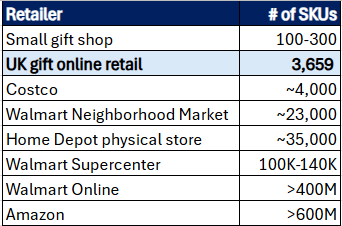

## Growth in monthly sales

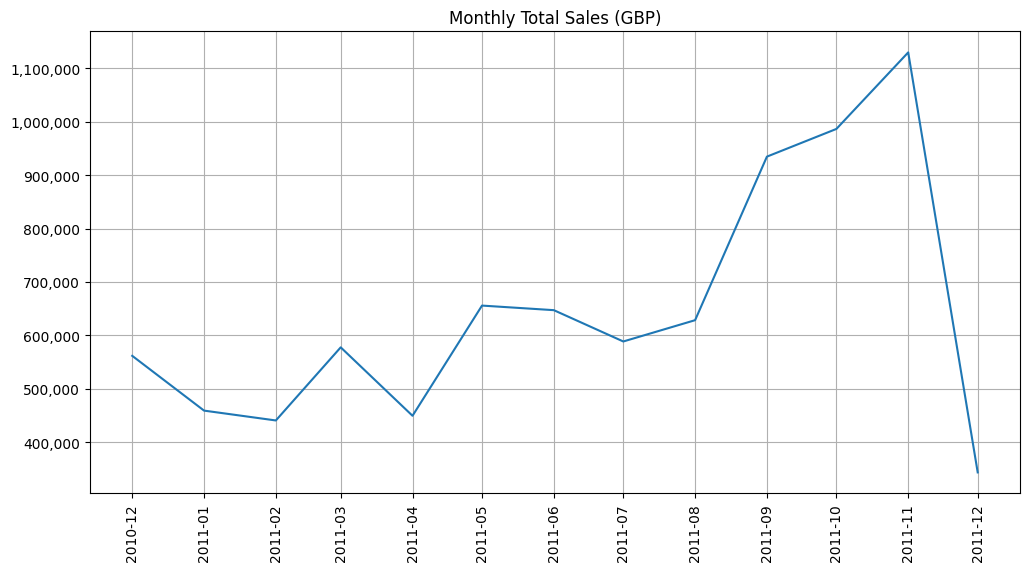

In [128]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# Convert 'InvoiceDate' to datetime and extract month and year
data_staging_5['InvoiceDate'] = pd.to_datetime(data_staging_5['InvoiceDate'])
data_staging_5['Month_Year'] = data_staging_5['InvoiceDate'].dt.to_period('M')

# Group by month and year and sum 'Invoice_Total_P'
monthly_sales = data_staging_5.groupby('Month_Year')['Invoice_Total_P'].sum().reset_index()

# Convert 'Month_Year' back to datetime for plotting
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()

# Create a line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Invoice_Total_P'])
plt.title('Monthly Total Sales (GBP)')
plt.grid(True)

# Format Y-axis labels
formatter = mticker.StrMethodFormatter('{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

# Show every month on X-axis and rotate labels and format
plt.xticks(monthly_sales['Month_Year'], rotation=90)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.show()

In [129]:
data_staging_5

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status,Invoice_Total_C,Invoice_Total_P,Month_Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,Completed,0.0,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,Completed,0.0,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2,Completed,0.0,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3,Completed,0.0,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4,Completed,0.0,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406880,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,406824,Completed,0.0,10.20,2011-12
406881,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,406825,Completed,0.0,12.60,2011-12
406882,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,406826,Completed,0.0,16.60,2011-12
406883,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,406827,Completed,0.0,16.60,2011-12


In [130]:
data_staging_6 = pd.merge(
    data_staging_5,
    Product_Master[['StockCode', 'Base_Price', 'Typical_Q', 'Popularity_Mon_Sale', 'Popularity_Uniq_Cust']],
    on='StockCode',
    how='left'
)

display(data_staging_6.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status,Invoice_Total_C,Invoice_Total_P,Month_Year,Base_Price,Typical_Q,Popularity_Mon_Sale,Popularity_Uniq_Cust
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,Completed,0.0,15.30,2010-12,5.79,6.0,65,98
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,Completed,0.0,20.34,2010-12,8.29,4.0,4,17
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2,Completed,0.0,22.00,2010-12,4.15,4.0,5,16
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3,Completed,0.0,20.34,2010-12,7.46,4.0,6,24
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4,Completed,0.0,20.34,2010-12,8.29,4.0,10,26


## Price Effect and Quanitiy Effect

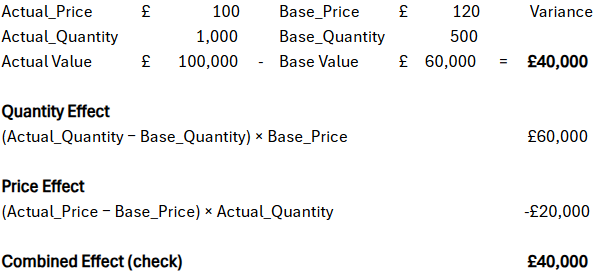

In [131]:
data_staging_7 = data_staging_6.copy()

data_staging_7['Base_Value'] = data_staging_7.apply(
    lambda row: row['Base_Price'] * row['Typical_Q'] if row['Invoice_Total_P'] > 0 else 0, axis=1
)

data_staging_7['Quantity_Effect'] = data_staging_7.apply(
    lambda row: (row['Quantity'] - row['Typical_Q']) * row['Base_Price'] if row['Invoice_Total_P'] > 0 else 0, axis=1
)

data_staging_7['Price_Effect'] = data_staging_7.apply(
    lambda row: (row['UnitPrice'] - row['Base_Price']) * row['Quantity'] if row['Invoice_Total_P'] > 0 else 0, axis=1
)

data_staging_7['Combined_Effect'] = data_staging_7['Quantity_Effect'] + data_staging_7['Price_Effect']

data_staging_7['AB_Variance'] = data_staging_7['Invoice_Total_P'] - data_staging_7['Base_Value']

display(data_staging_7.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Item_ID,Status,...,Month_Year,Base_Price,Typical_Q,Popularity_Mon_Sale,Popularity_Uniq_Cust,Base_Value,Quantity_Effect,Price_Effect,Combined_Effect,AB_Variance
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,Completed,...,2010-12,5.79,6.0,65,98,34.74,0.00,-19.44,-19.44,-19.44
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,Completed,...,2010-12,8.29,4.0,4,17,33.16,16.58,-29.40,-12.82,-12.82
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2,Completed,...,2010-12,4.15,4.0,5,16,16.60,16.60,-11.20,5.40,5.40
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3,Completed,...,2010-12,7.46,4.0,6,24,29.84,14.92,-24.42,-9.50,-9.50
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4,Completed,...,2010-12,8.29,4.0,10,26,33.16,16.58,-29.40,-12.82,-12.82


## Invoice Analytics

In [132]:
data_staging_invoice_1 = data_staging_7.groupby('InvoiceNo').agg(
    InvoiceDate=('InvoiceDate', 'first'),
    CustomerID=('CustomerID', 'first'),
    Country=('Country', 'first'),
    Invoice_Total_C=('Invoice_Total_C', 'sum'),
    Invoice_Total_P=('Invoice_Total_P', 'sum'),
    Base_Value=('Base_Value', 'sum'),
    Quantity_Effect=('Quantity_Effect', 'sum'),
    Price_Effect=('Price_Effect', 'sum'),
    Number_of_Items=('InvoiceNo', 'count'),
    Avg_Pop_Mon_Sale=('Popularity_Mon_Sale', 'mean'),
    Min_Pop_Mon_Sale=('Popularity_Mon_Sale', 'min'),
    Max_Pop_Mon_Sale=('Popularity_Mon_Sale', 'max'),
    Avg_Pop_Uniq_Cust=('Popularity_Uniq_Cust', 'mean'),
    Min_Pop_Uniq_Cust=('Popularity_Uniq_Cust', 'min'),
    Max_Pop_Uniq_Cust=('Popularity_Uniq_Cust', 'max'),

).reset_index()

data_staging_invoice_1['Net_Proceeds'] = data_staging_invoice_1['Invoice_Total_P'] - data_staging_invoice_1['Invoice_Total_C']
data_staging_invoice_1['Combined_Effect'] = data_staging_invoice_1['Quantity_Effect'] + data_staging_invoice_1['Price_Effect']
data_staging_invoice_1['AB_Variance'] = data_staging_invoice_1['Invoice_Total_P'] - data_staging_invoice_1['Base_Value']

display(data_staging_invoice_1.head())

,InvoiceNo,InvoiceDate,CustomerID,Country,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Net_Proceeds,Combined_Effect,AB_Variance
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,0.0,139.12,210.64,94.56,-166.08,7,14.428571,2,65,30.285714,9,98,139.12,-71.52,-71.52
1,536366,2010-12-01 08:28:00,17850.0,United Kingdom,0.0,22.20,21.00,4.20,-3.00,2,6.000000,6,6,32.500000,30,35,22.20,1.20,1.20
2,536367,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,278.73,319.89,137.28,-178.44,12,8.250000,1,36,27.250000,1,77,278.73,-41.16,-41.16
3,536368,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,70.05,74.49,19.80,-24.24,4,6.250000,1,21,24.250000,9,66,70.05,-4.44,-4.44
4,536369,2010-12-01 08:35:00,13047.0,United Kingdom,0.0,17.85,34.89,0.00,-17.04,1,3.000000,3,3,20.000000,20,20,17.85,-17.04,-17.04


Distribution of CustomerID by Country:


,Country,Number_of_Customers
0,United Kingdom,3916
1,Germany,94
2,France,87
3,Spain,30
4,Belgium,25


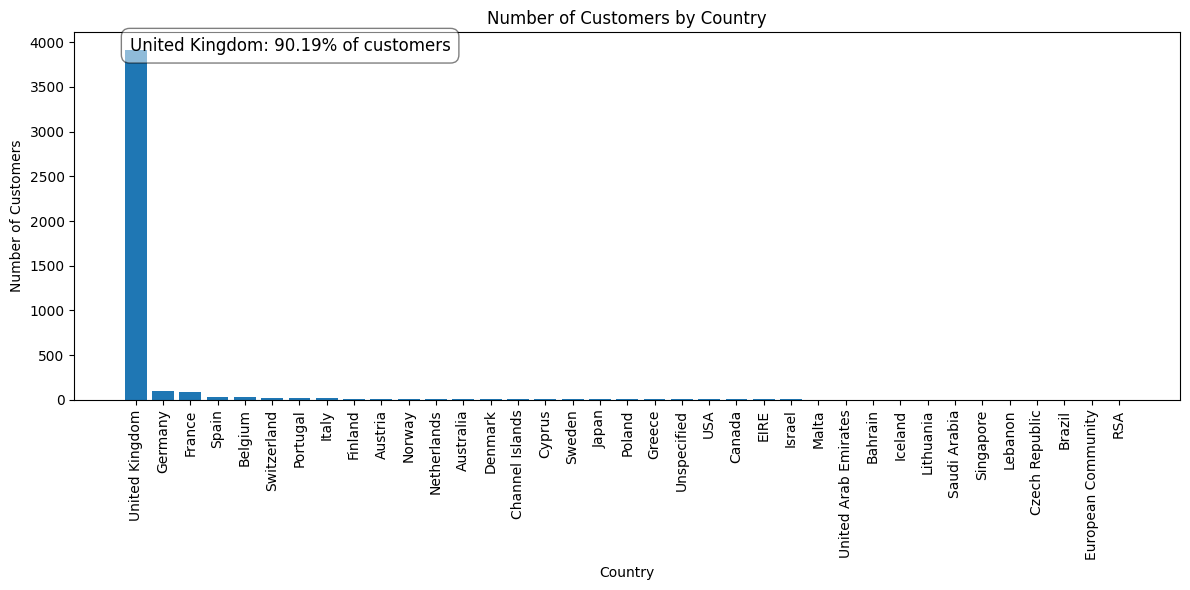

In [133]:
# Create a temporary table of unique CustomerID and Country
customer_country = data_staging_invoice_1[['CustomerID', 'Country']].drop_duplicates()

# Calculate the distribution of CustomerID by Country
country_distribution = customer_country['Country'].value_counts().reset_index()
country_distribution.columns = ['Country', 'Number_of_Customers']

# Calculate the percentage of customers from the United Kingdom
uk_customer_count = country_distribution[country_distribution['Country'] == 'United Kingdom']['Number_of_Customers'].sum()
total_customer_count = country_distribution['Number_of_Customers'].sum()
uk_percentage = (uk_customer_count / total_customer_count) * 100

# Display the distribution
print("Distribution of CustomerID by Country:")
display(country_distribution.head())

# Create a bar chart of the distribution
plt.figure(figsize=(12, 6))
plt.bar(country_distribution['Country'], country_distribution['Number_of_Customers'])
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by Country')
plt.xticks(rotation=90)
plt.tight_layout()

# Add annotation for UK customer percentage
plt.annotate(f'United Kingdom: {uk_percentage:.2f}% of customers',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))


plt.show()

## Invoices: Transaction Timing

In [134]:
data_staging_invoice_2 = data_staging_invoice_1.copy()
data_staging_invoice_2['InvoiceDate_Dt'] = data_staging_invoice_2['InvoiceDate'].dt.date
data_staging_invoice_2['InvoiceDate_Tm'] = data_staging_invoice_2['InvoiceDate'].dt.time
data_staging_invoice_2['Weekend_Transaction'] = data_staging_invoice_2['InvoiceDate_Dt'].apply(lambda x: 1 if x.weekday() >= 5 else 0)

# Add column Out_of_Bus_Hrs
import datetime
data_staging_invoice_2['Out_of_Bus_Hrs'] = data_staging_invoice_2['InvoiceDate_Tm'].apply(lambda x: 1 if x < datetime.time(9, 0) or x >= datetime.time(17, 0) else 0)

data_staging_invoice_2.head()

,InvoiceNo,InvoiceDate,CustomerID,Country,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Number_of_Items,...,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Net_Proceeds,Combined_Effect,AB_Variance,InvoiceDate_Dt,InvoiceDate_Tm,Weekend_Transaction,Out_of_Bus_Hrs
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,0.0,139.12,210.64,94.56,-166.08,7,...,30.285714,9,98,139.12,-71.52,-71.52,2010-12-01,08:26:00,0,1
1,536366,2010-12-01 08:28:00,17850.0,United Kingdom,0.0,22.20,21.00,4.20,-3.00,2,...,32.500000,30,35,22.20,1.20,1.20,2010-12-01,08:28:00,0,1
2,536367,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,278.73,319.89,137.28,-178.44,12,...,27.250000,1,77,278.73,-41.16,-41.16,2010-12-01,08:34:00,0,1
3,536368,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,70.05,74.49,19.80,-24.24,4,...,24.250000,9,66,70.05,-4.44,-4.44,2010-12-01,08:34:00,0,1
4,536369,2010-12-01 08:35:00,13047.0,United Kingdom,0.0,17.85,34.89,0.00,-17.04,1,...,20.000000,20,20,17.85,-17.04,-17.04,2010-12-01,08:35:00,0,1


In [135]:
# Create a temporary table to show distribution of weekday
weekday_distribution = data_staging_invoice_2['InvoiceDate_Dt'].apply(lambda x: x.weekday()).value_counts().sort_index()

# Map weekday numbers to names
weekday_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday_distribution.index = weekday_distribution.index.map(weekday_names)

display(weekday_distribution)

,count
InvoiceDate_Dt,
Monday,2830
Tuesday,3156
Wednesday,3436
Thursday,4003
Friday,2809
Sunday,2168


In [136]:
# Extract the hour from InvoiceDate_Tm and count the occurrences
hourly_distribution = data_staging_invoice_2['InvoiceDate_Tm'].apply(lambda x: x.hour).value_counts().sort_index()

# Display the distribution
print("Distribution of transactions by hour of the day:")
display(hourly_distribution)

# Calculate and show % of rows with Out_of_Bus_Hrs = 1
out_of_bus_hours_percentage = (data_staging_invoice_2['Out_of_Bus_Hrs'].sum() / len(data_staging_invoice_2)) * 100
print(f"\nPercentage of transactions outside business hours: {out_of_bus_hours_percentage:.2f}%")

Distribution of transactions by hour of the day:


,count
InvoiceDate_Tm,
6,1
7,29
8,554
9,1383
10,2204
11,2262
12,3117
13,2623
14,2251



Percentage of transactions outside business hours: 7.90%


In [137]:
data_staging_invoice_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18402 entries, 0 to 18401
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   InvoiceNo            18402 non-null  object        
 1   InvoiceDate          18402 non-null  datetime64[ns]
 2   CustomerID           18402 non-null  float64       
 3   Country              18402 non-null  object        
 4   Invoice_Total_C      18402 non-null  float64       
 5   Invoice_Total_P      18402 non-null  float64       
 6   Base_Value           18402 non-null  float64       
 7   Quantity_Effect      18402 non-null  float64       
 8   Price_Effect         18402 non-null  float64       
 9   Number_of_Items      18402 non-null  int64         
 10  Avg_Pop_Mon_Sale     18402 non-null  float64       
 11  Min_Pop_Mon_Sale     18402 non-null  int64         
 12  Max_Pop_Mon_Sale     18402 non-null  int64         
 13  Avg_Pop_Uniq_Cust    18402 non-

In [138]:
earliest_date = data_staging_invoice_2['InvoiceDate_Dt'].min()
latest_date = data_staging_invoice_2['InvoiceDate_Dt'].max()

# Calculate the duration of the period in days
time_difference = (latest_date - earliest_date).days
midpoint_date = earliest_date + (latest_date - earliest_date) / 2

print(f"Earliest Invoice Date: {earliest_date}")
print(f"Latest Invoice Date: {latest_date}")
print(f"Midpoint Date: {midpoint_date}")
print(f"Duration of observations: {time_difference}")

Earliest Invoice Date: 2010-12-01
Latest Invoice Date: 2011-12-09
Midpoint Date: 2011-06-05
Duration of observations: 373


## Invoices: Sales Growth

In [139]:
data_staging_invoice_3 = data_staging_invoice_2.copy()

data_staging_invoice_3['Sale_1st_Half'] = data_staging_invoice_3.apply(
    lambda row: row['Invoice_Total_P'] if row['InvoiceDate_Dt'] <= midpoint_date else 0, axis=1
)

data_staging_invoice_3['Sale_2nd_Half'] = data_staging_invoice_3.apply(
    lambda row: row['Invoice_Total_P'] if row['InvoiceDate_Dt'] > midpoint_date else 0, axis=1
)

display(data_staging_invoice_3.head())

,InvoiceNo,InvoiceDate,CustomerID,Country,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Number_of_Items,...,Max_Pop_Uniq_Cust,Net_Proceeds,Combined_Effect,AB_Variance,InvoiceDate_Dt,InvoiceDate_Tm,Weekend_Transaction,Out_of_Bus_Hrs,Sale_1st_Half,Sale_2nd_Half
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,0.0,139.12,210.64,94.56,-166.08,7,...,98,139.12,-71.52,-71.52,2010-12-01,08:26:00,0,1,139.12,0.0
1,536366,2010-12-01 08:28:00,17850.0,United Kingdom,0.0,22.20,21.00,4.20,-3.00,2,...,35,22.20,1.20,1.20,2010-12-01,08:28:00,0,1,22.20,0.0
2,536367,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,278.73,319.89,137.28,-178.44,12,...,77,278.73,-41.16,-41.16,2010-12-01,08:34:00,0,1,278.73,0.0
3,536368,2010-12-01 08:34:00,13047.0,United Kingdom,0.0,70.05,74.49,19.80,-24.24,4,...,66,70.05,-4.44,-4.44,2010-12-01,08:34:00,0,1,70.05,0.0
4,536369,2010-12-01 08:35:00,13047.0,United Kingdom,0.0,17.85,34.89,0.00,-17.04,1,...,20,17.85,-17.04,-17.04,2010-12-01,08:35:00,0,1,17.85,0.0


## Client Analytics

In [140]:
data_staging_client_1 = data_staging_invoice_3.groupby('CustomerID').agg(
    Country=('Country', 'first'),
    Total_invoices=('InvoiceNo', 'count'),
    Invoice_Total_C=('Invoice_Total_C', 'sum'),
    Invoice_Total_P=('Invoice_Total_P', 'sum'),
    Base_Value=('Base_Value', 'sum'),
    Quantity_Effect=('Quantity_Effect', 'sum'),
    Price_Effect=('Price_Effect', 'sum'),
    Avg_Number_of_Items=('Number_of_Items', 'mean'),
    Avg_Pop_Mon_Sale=('Avg_Pop_Mon_Sale', 'mean'),
    Min_Pop_Mon_Sale=('Min_Pop_Mon_Sale', 'min'),
    Max_Pop_Mon_Sale=('Max_Pop_Mon_Sale', 'max'),
    Avg_Pop_Uniq_Cust=('Avg_Pop_Uniq_Cust', 'mean'),
    Min_Pop_Uniq_Cust=('Min_Pop_Uniq_Cust', 'min'),
    Max_Pop_Uniq_Cust=('Max_Pop_Uniq_Cust', 'max'),
    Avg_Net_Proceeds=('Invoice_Total_P', 'mean'),
    Weekend_Transaction = ('Weekend_Transaction', 'sum'),
    Out_of_Bus_Hrs = ('Out_of_Bus_Hrs', 'sum'),
    Sale_1st_Half = ('Sale_1st_Half', 'sum'),
    Sale_2nd_Half = ('Sale_2nd_Half', 'sum')
).reset_index()

display(data_staging_client_1.head())

,CustomerID,Country,Total_invoices,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Avg_Net_Proceeds,Weekend_Transaction,Out_of_Bus_Hrs,Sale_1st_Half,Sale_2nd_Half
0,12346.0,United Kingdom,1,77183.6,0.00,0.000,0.000,0.00,1.00,58.000000,58,58,16.000000,16,16,0.000000,0,0,0.00,0.00
1,12347.0,Iceland,7,0.0,4310.00,3759.550,3675.580,-3125.13,26.00,6.746545,1,94,20.255216,1,100,615.714286,0,1,1823.43,2486.57
2,12348.0,Finland,4,0.0,1437.24,480.825,1833.855,-877.44,6.75,4.381250,1,8,22.540625,3,47,359.310000,1,1,1167.24,270.00
3,12349.0,Italy,1,0.0,1457.55,1655.460,701.160,-899.07,72.00,6.722222,1,94,24.138889,5,100,1457.550000,0,0,0.00,1457.55
4,12350.0,Norway,1,0.0,294.40,223.580,263.180,-192.36,16.00,3.187500,1,16,15.750000,2,40,294.400000,0,0,294.40,0.00


In [141]:
data_staging_client_2 = data_staging_client_1.copy()

# Calculate Avg_Monthly_Invoices, handling division by zero if time_difference is 0
data_staging_client_2['Avg_Monthly_Invoices'] = data_staging_client_2['Total_invoices'] / time_difference * 30 if time_difference != 0 else 0

# Calculate Cancelled_Perc, handling division by zero
data_staging_client_2['Cancelled_Perc'] = data_staging_client_2.apply(
    lambda row: row['Invoice_Total_C'] / (row['Invoice_Total_C'] + row['Invoice_Total_P']) if (row['Invoice_Total_C'] + row['Invoice_Total_P']) != 0 else 0, axis=1
)

# Calculate Quantity_Effect_Perc, handling division by zero
data_staging_client_2['Quantity_Effect_Perc'] = data_staging_client_2.apply(
    lambda row: row['Quantity_Effect'] / row['Base_Value'] if row['Base_Value'] != 0 else 0, axis=1
)

# Calculate Price_Effect_Perc, handling division by zero
data_staging_client_2['Price_Effect_Perc'] = data_staging_client_2.apply(
    lambda row: row['Price_Effect'] / row['Base_Value'] if row['Base_Value'] != 0 else 0, axis=1
)

# Calculate Weekend_Transaction_Perc, handling division by zero
data_staging_client_2['Weekend_Transaction_Perc'] = data_staging_client_2.apply(
    lambda row: row['Weekend_Transaction'] / row['Total_invoices'] if row['Total_invoices'] != 0 else 0, axis=1
)

# Calculate Out_of_Bus_Hrs_Perc, handling division by zero
data_staging_client_2['Out_of_Bus_Hrs_Perc'] = data_staging_client_2.apply(
    lambda row: row['Out_of_Bus_Hrs'] / row['Total_invoices'] if row['Total_invoices'] != 0 else 0, axis=1
)

# Calculate Sales_Growth, handling division by zero
data_staging_client_2['Sales_Growth'] = data_staging_client_2.apply(
    lambda row: row['Sale_2nd_Half'] / row['Sale_1st_Half'] if row['Sale_1st_Half'] != 0 else 0, axis=1
)

# Add UK_or_Not column
data_staging_client_2['UK_or_Not'] = data_staging_client_2['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)


display(data_staging_client_2.head())

,CustomerID,Country,Total_invoices,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Avg_Number_of_Items,Avg_Pop_Mon_Sale,...,Sale_1st_Half,Sale_2nd_Half,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Price_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not
0,12346.0,United Kingdom,1,77183.6,0.00,0.000,0.000,0.00,1.00,58.000000,...,0.00,0.00,0.080429,1.0,0.000000,0.000000,0.00,0.000000,0.000000,1
1,12347.0,Iceland,7,0.0,4310.00,3759.550,3675.580,-3125.13,26.00,6.746545,...,1823.43,2486.57,0.563003,0.0,0.977665,-0.831251,0.00,0.142857,1.363677,0
2,12348.0,Finland,4,0.0,1437.24,480.825,1833.855,-877.44,6.75,4.381250,...,1167.24,270.00,0.321716,0.0,3.813976,-1.824864,0.25,0.250000,0.231315,0
3,12349.0,Italy,1,0.0,1457.55,1655.460,701.160,-899.07,72.00,6.722222,...,0.00,1457.55,0.080429,0.0,0.423544,-0.543094,0.00,0.000000,0.000000,0
4,12350.0,Norway,1,0.0,294.40,223.580,263.180,-192.36,16.00,3.187500,...,294.40,0.00,0.080429,0.0,1.177118,-0.860363,0.00,0.000000,0.000000,0


In [142]:
data_staging_client_2.describe()

,CustomerID,Total_invoices,Invoice_Total_C,Invoice_Total_P,Base_Value,Quantity_Effect,Price_Effect,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,...,Sale_1st_Half,Sale_2nd_Half,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Price_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not
count,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,...,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000
mean,15299.251731,4.245962,82.466675,1939.207416,2144.505868,1651.439287,-1856.737739,22.301270,7.485369,1.513844,...,744.900369,1194.307047,0.341498,0.008377,1.656211,-1.221190,0.127722,0.082458,0.848363,0.903553
std,1721.994109,7.634989,2836.790583,8350.306156,4948.576347,16009.024225,9485.463549,20.670648,5.602849,3.919236,...,3062.459463,5552.179244,0.614074,0.054164,11.311404,5.599725,0.268366,0.211711,2.694035,0.295237
min,12346.000000,1.000000,0.000000,0.000000,0.000000,-75981.670000,-361170.930000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.080429,0.000000,-0.833333,-200.051125,0.000000,0.000000,0.000000,0.000000
25%,13812.250000,1.000000,0.000000,302.610000,390.263750,-15.925000,-1328.540000,9.462500,4.568205,1.000000,...,0.000000,119.140000,0.080429,0.000000,-0.037498,-0.822298,0.000000,0.000000,0.000000,1.000000
50%,15297.500000,2.000000,0.000000,659.425000,926.912500,180.767500,-489.725000,17.000000,6.322479,1.000000,...,212.285000,400.720000,0.160858,0.000000,0.278974,-0.527089,0.000000,0.000000,0.000000,1.000000
75%,16778.750000,5.000000,0.000000,1620.970000,2333.618750,820.645000,-206.072500,28.383333,8.761742,1.000000,...,632.925000,1032.602500,0.402145,0.000000,0.846956,-0.342361,0.111111,0.000000,1.116993,1.000000
max,18287.000000,206.000000,168469.600000,278778.020000,144758.390000,609590.405000,0.000000,299.705882,94.000000,94.000000,...,115577.920000,195015.190000,16.568365,1.000000,389.600000,0.000000,1.000000,1.000000,135.717207,1.000000


In [143]:
data_staging_client_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4334 non-null   float64
 1   Country                   4334 non-null   object 
 2   Total_invoices            4334 non-null   int64  
 3   Invoice_Total_C           4334 non-null   float64
 4   Invoice_Total_P           4334 non-null   float64
 5   Base_Value                4334 non-null   float64
 6   Quantity_Effect           4334 non-null   float64
 7   Price_Effect              4334 non-null   float64
 8   Avg_Number_of_Items       4334 non-null   float64
 9   Avg_Pop_Mon_Sale          4334 non-null   float64
 10  Min_Pop_Mon_Sale          4334 non-null   int64  
 11  Max_Pop_Mon_Sale          4334 non-null   int64  
 12  Avg_Pop_Uniq_Cust         4334 non-null   float64
 13  Min_Pop_Uniq_Cust         4334 non-null   int64  
 14  Max_Pop_

## Final Dataset Preparation

In [144]:
data_final = data_staging_client_2.drop(columns=['CustomerID', 'Country', 'Total_invoices', 'Sale_1st_Half', 'Sale_2nd_Half',
                                                 'Quantity_Effect', 'Price_Effect', 'Invoice_Total_C', 'Invoice_Total_P','Base_Value',
                                                 'Weekend_Transaction', 'Out_of_Bus_Hrs']).copy()
display(data_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Avg_Number_of_Items       4334 non-null   float64
 1   Avg_Pop_Mon_Sale          4334 non-null   float64
 2   Min_Pop_Mon_Sale          4334 non-null   int64  
 3   Max_Pop_Mon_Sale          4334 non-null   int64  
 4   Avg_Pop_Uniq_Cust         4334 non-null   float64
 5   Min_Pop_Uniq_Cust         4334 non-null   int64  
 6   Max_Pop_Uniq_Cust         4334 non-null   int64  
 7   Avg_Net_Proceeds          4334 non-null   float64
 8   Avg_Monthly_Invoices      4334 non-null   float64
 9   Cancelled_Perc            4334 non-null   float64
 10  Quantity_Effect_Perc      4334 non-null   float64
 11  Price_Effect_Perc         4334 non-null   float64
 12  Weekend_Transaction_Perc  4334 non-null   float64
 13  Out_of_Bus_Hrs_Perc       4334 non-null   float64
 14  Sales_Gr

None

In [145]:
data_final['Price_Effect_Perc_Neg'] = -data_final['Price_Effect_Perc']
data_final.drop(columns=['Price_Effect_Perc'], inplace=True)
display(data_final.head())

,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Avg_Net_Proceeds,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not,Price_Effect_Perc_Neg
0,1.00,58.000000,58,58,16.000000,16,16,0.000000,0.080429,1.0,0.000000,0.00,0.000000,0.000000,1,-0.000000
1,26.00,6.746545,1,94,20.255216,1,100,615.714286,0.563003,0.0,0.977665,0.00,0.142857,1.363677,0,0.831251
2,6.75,4.381250,1,8,22.540625,3,47,359.310000,0.321716,0.0,3.813976,0.25,0.250000,0.231315,0,1.824864
3,72.00,6.722222,1,94,24.138889,5,100,1457.550000,0.080429,0.0,0.423544,0.00,0.000000,0.000000,0,0.543094
4,16.00,3.187500,1,16,15.750000,2,40,294.400000,0.080429,0.0,1.177118,0.00,0.000000,0.000000,0,0.860363


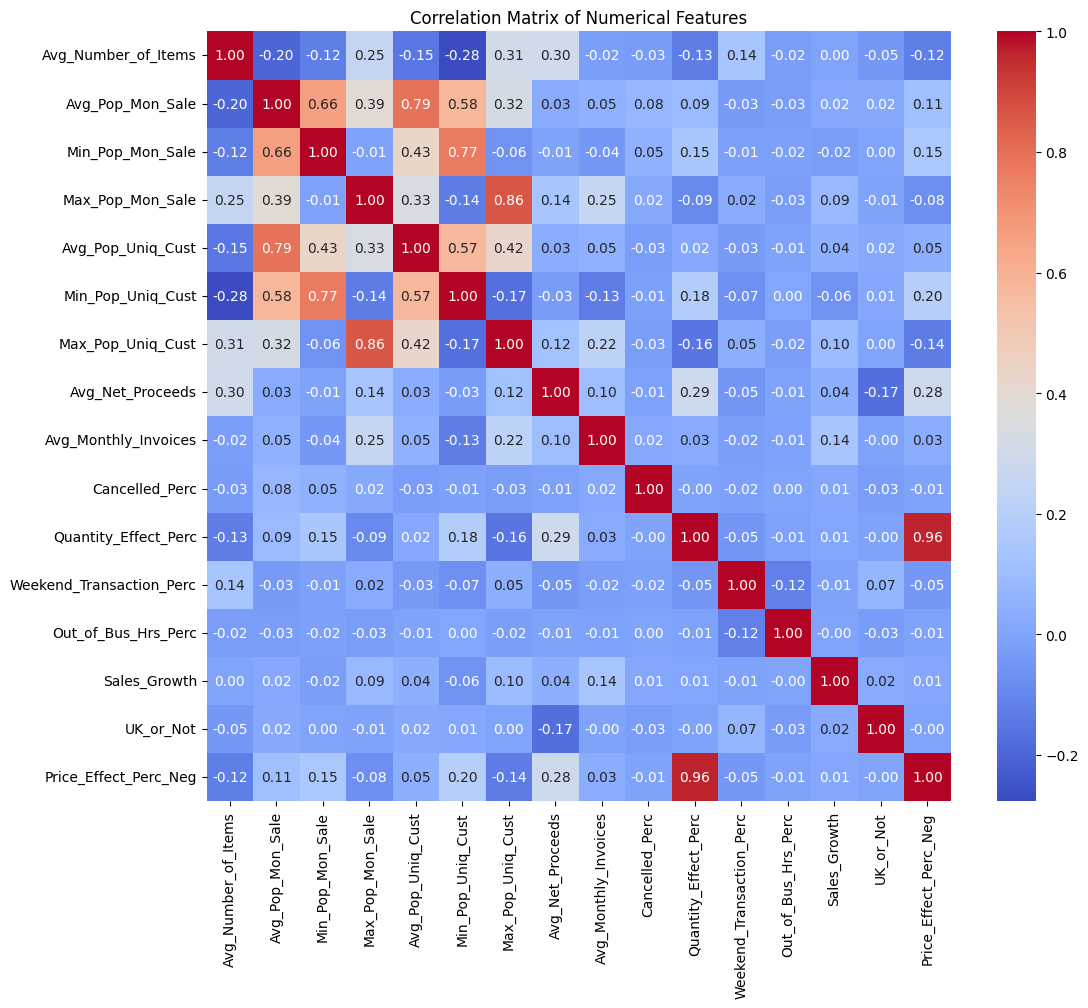

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data_final.select_dtypes(include=['float64', 'int64']).corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# K-means clustering

## Scaling Data

K-Means clustering relies on measuring distances between data points, so if features are on different scales, those with larger values can dominate the results and distort the segmentation. Scaling ensures that all features contribute fairly, helping the algorithm identify meaningful customer groups rather than just reacting to numerical magnitude.

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = data_final.select_dtypes(include=['float64', 'int64']).columns
data_scaled_array = scaler.fit_transform(data_final[numerical_cols])
data_scaled = pd.DataFrame(data_scaled_array, columns=numerical_cols)
display(data_scaled.head())

,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Avg_Net_Proceeds,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not,Price_Effect_Perc_Neg
0,-1.030627,9.016923,14.414205,0.401509,-1.030775,1.594704,-2.388763,-0.794962,-0.425192,18.309747,-0.146437,-0.475980,-0.389527,-0.314941,0.326713,-0.218105
1,0.178957,-0.131881,-0.131123,1.576420,-0.533791,-0.546610,1.119066,0.511958,0.360754,-0.154671,-0.059995,-0.475980,0.285325,0.191302,-3.060788,-0.069643
2,-0.752423,-0.554089,-0.131123,-1.230311,-0.266869,-0.261101,-1.094207,-0.032288,-0.032219,-0.154671,0.190782,0.455692,0.791464,-0.229069,-3.060788,0.107817
3,2.404592,-0.136223,-0.131123,1.576420,-0.080201,0.024407,1.119066,2.298846,-0.425192,-0.154671,-0.108988,-0.475980,-0.389527,-0.314941,-3.060788,-0.121109
4,-0.304877,-0.767175,-0.131123,-0.969220,-1.059974,-0.403855,-1.386526,-0.170066,-0.425192,-0.154671,-0.042360,-0.475980,-0.389527,-0.314941,-3.060788,-0.064444


## Original Model

In [148]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(data_scaled)
data_final['Cluster_Label'] = kmeans.labels_
display(data_final.head())

,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Avg_Net_Proceeds,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not,Price_Effect_Perc_Neg,Cluster_Label
0,1.00,58.000000,58,58,16.000000,16,16,0.000000,0.080429,1.0,0.000000,0.00,0.000000,0.000000,1,-0.000000,4
1,26.00,6.746545,1,94,20.255216,1,100,615.714286,0.563003,0.0,0.977665,0.00,0.142857,1.363677,0,0.831251,2
2,6.75,4.381250,1,8,22.540625,3,47,359.310000,0.321716,0.0,3.813976,0.25,0.250000,0.231315,0,1.824864,2
3,72.00,6.722222,1,94,24.138889,5,100,1457.550000,0.080429,0.0,0.423544,0.00,0.000000,0.000000,0,0.543094,2
4,16.00,3.187500,1,16,15.750000,2,40,294.400000,0.080429,0.0,1.177118,0.00,0.000000,0.000000,0,0.860363,2


## Tuning the number of clusters

In [149]:
inertia = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

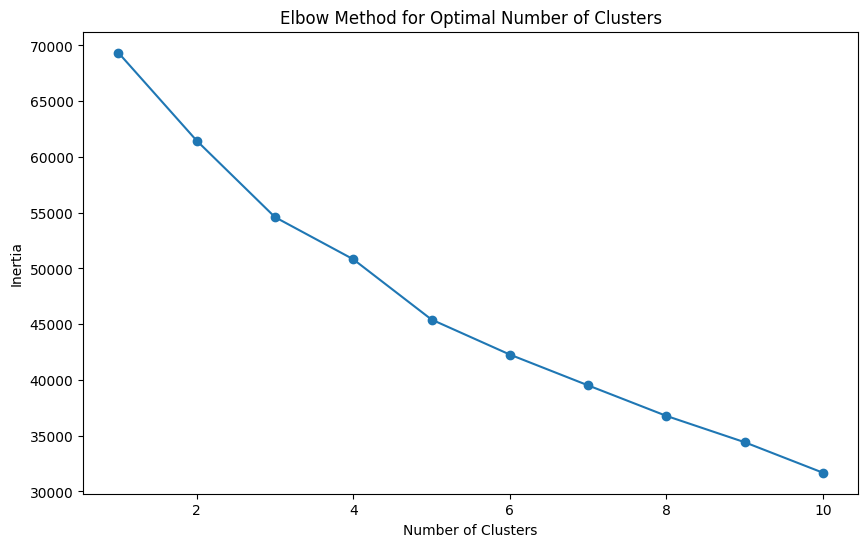

In [150]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

## Final Model

In [157]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=2025, n_init=100)
kmeans.fit(data_scaled)
data_final['Cluster_Label'] = kmeans.labels_
display(data_final.head())

,Avg_Number_of_Items,Avg_Pop_Mon_Sale,Min_Pop_Mon_Sale,Max_Pop_Mon_Sale,Avg_Pop_Uniq_Cust,Min_Pop_Uniq_Cust,Max_Pop_Uniq_Cust,Avg_Net_Proceeds,Avg_Monthly_Invoices,Cancelled_Perc,Quantity_Effect_Perc,Weekend_Transaction_Perc,Out_of_Bus_Hrs_Perc,Sales_Growth,UK_or_Not,Price_Effect_Perc_Neg,Cluster_Label
0,1.00,58.000000,58,58,16.000000,16,16,0.000000,0.080429,1.0,0.000000,0.00,0.000000,0.000000,1,-0.000000,2
1,26.00,6.746545,1,94,20.255216,1,100,615.714286,0.563003,0.0,0.977665,0.00,0.142857,1.363677,0,0.831251,5
2,6.75,4.381250,1,8,22.540625,3,47,359.310000,0.321716,0.0,3.813976,0.25,0.250000,0.231315,0,1.824864,5
3,72.00,6.722222,1,94,24.138889,5,100,1457.550000,0.080429,0.0,0.423544,0.00,0.000000,0.000000,0,0.543094,5
4,16.00,3.187500,1,16,15.750000,2,40,294.400000,0.080429,0.0,1.177118,0.00,0.000000,0.000000,0,0.860363,5


## Segment Statistics

In [158]:
cluster_characteristics = data_final.groupby('Cluster_Label').mean().T
display(cluster_characteristics)

Cluster_Label,0,1,2,3,4,5
Avg_Number_of_Items,32.441439,25.383627,1.066667,1.000000,16.834525,25.290541
Avg_Pop_Mon_Sale,6.135971,9.843067,58.733333,12.000000,5.412399,6.916242
Min_Pop_Mon_Sale,1.119617,1.218960,58.000000,12.000000,1.453024,1.223844
Max_Pop_Mon_Sale,42.595694,74.060550,59.466667,12.000000,21.131749,46.459854
Avg_Pop_Uniq_Cust,22.915949,28.639230,75.766667,25.333333,21.645587,24.063055
Min_Pop_Uniq_Cust,3.337321,3.952905,75.266667,25.333333,5.449784,4.313869
Max_Pop_Uniq_Cust,73.416268,93.229358,76.266667,25.333333,55.513499,73.260341
Avg_Net_Proceeds,291.884816,407.976184,172.603556,3386.640000,290.340363,690.187616
Avg_Monthly_Invoices,0.210116,0.533733,0.107239,0.080429,0.209107,0.317411
Cancelled_Perc,0.005477,0.007706,0.066667,0.000000,0.007942,0.013887


## Visualization: PCA

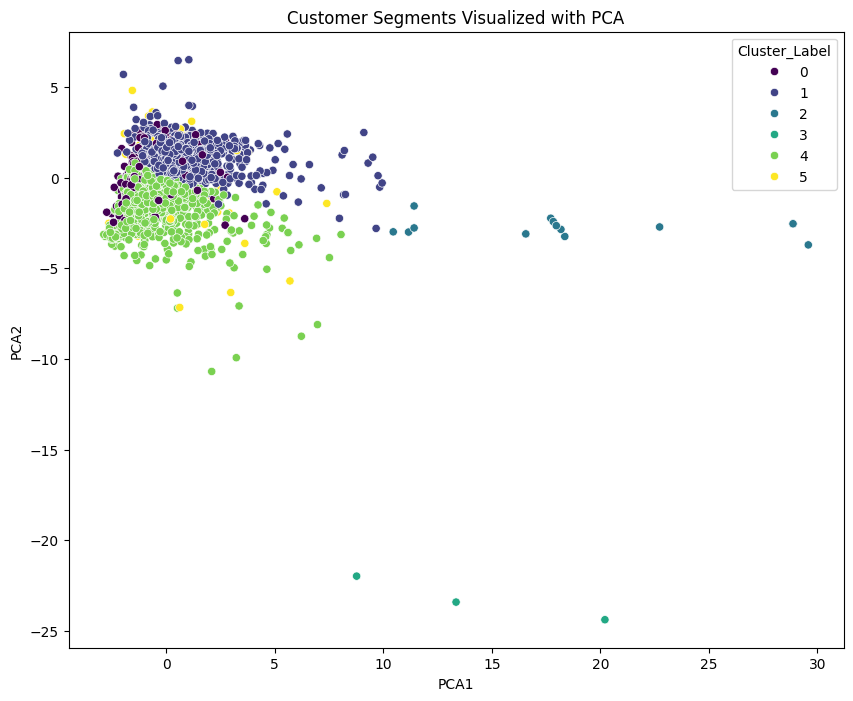

In [159]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster_Label'] = data_final['Cluster_Label']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=pca_df, palette='viridis', legend='full')
plt.title('Customer Segments Visualized with PCA')
plt.show()

## Visualization: Histogram

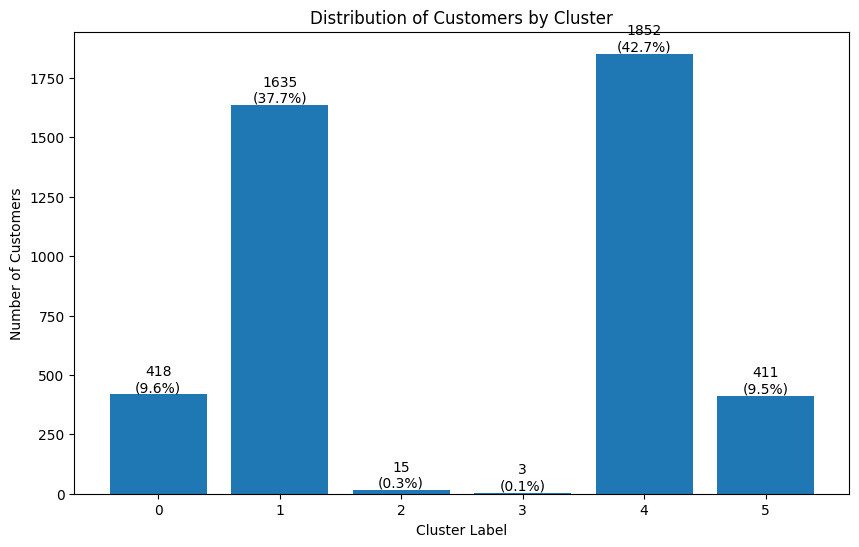

In [160]:
# Calculate the number of customers in each cluster
cluster_counts = data_final['Cluster_Label'].value_counts().sort_index()

# Calculate the percentage of customers in each cluster
total_customers = len(data_final)
cluster_percentages = (cluster_counts / total_customers) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster Label')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Cluster')
plt.xticks(cluster_counts.index)

# Add text labels for counts and percentages
for bar in bars:
    height = bar.get_height()
    cluster = bar.get_x() + bar.get_width()/2.
    count = cluster_counts[int(cluster)]
    percentage = cluster_percentages[int(cluster)]
    plt.text(cluster, height, f'{count}\n({percentage:.1f}%)', ha='center', va='bottom')


plt.show()

## Visualization: Radial Chart

In [161]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# Select the specified features from the cluster_characteristics DataFrame
features_for_radial = [
    'Avg_Number_of_Items',
    'Avg_Pop_Mon_Sale',
    'Avg_Pop_Uniq_Cust',
    'Avg_Net_Proceeds',
    'Avg_Monthly_Invoices',
    'Cancelled_Perc',
    'Quantity_Effect_Perc',
    'Price_Effect_Perc_Neg',
    'Weekend_Transaction_Perc',
    'Sales_Growth',
    'UK_or_Not'
]

radial_data = cluster_characteristics.loc[features_for_radial].T

# Apply RobustScaler first to reduce the effect of outliers
robust_scaler = RobustScaler()
radial_data_robust_scaled = robust_scaler.fit_transform(radial_data)

# Then apply MinMaxScaler to scale the data to the 0-1 range
min_max_scaler = MinMaxScaler()
radial_data_scaled_array = min_max_scaler.fit_transform(radial_data_robust_scaled)

# Create a DataFrame from the scaled array
radial_data_scaled = pd.DataFrame(radial_data_scaled_array, columns=radial_data.columns, index=radial_data.index)


# Transpose the data for plotting (features as columns, clusters as rows)
radial_data_transposed = radial_data_scaled.T

display(radial_data_transposed.head())

Cluster_Label,0,1,2,3,4,5
Avg_Number_of_Items,1.000000,0.775525,0.002120,0.000000,0.503620,0.772565
Avg_Pop_Mon_Sale,0.013570,0.083094,1.000000,0.123546,0.000000,0.028204
Avg_Pop_Uniq_Cust,0.023473,0.129222,1.000000,0.068139,0.000000,0.044668
Avg_Net_Proceeds,0.037113,0.073233,0.000000,1.000000,0.036632,0.161039
Avg_Monthly_Invoices,0.286092,1.000000,0.059143,0.000000,0.283866,0.522787


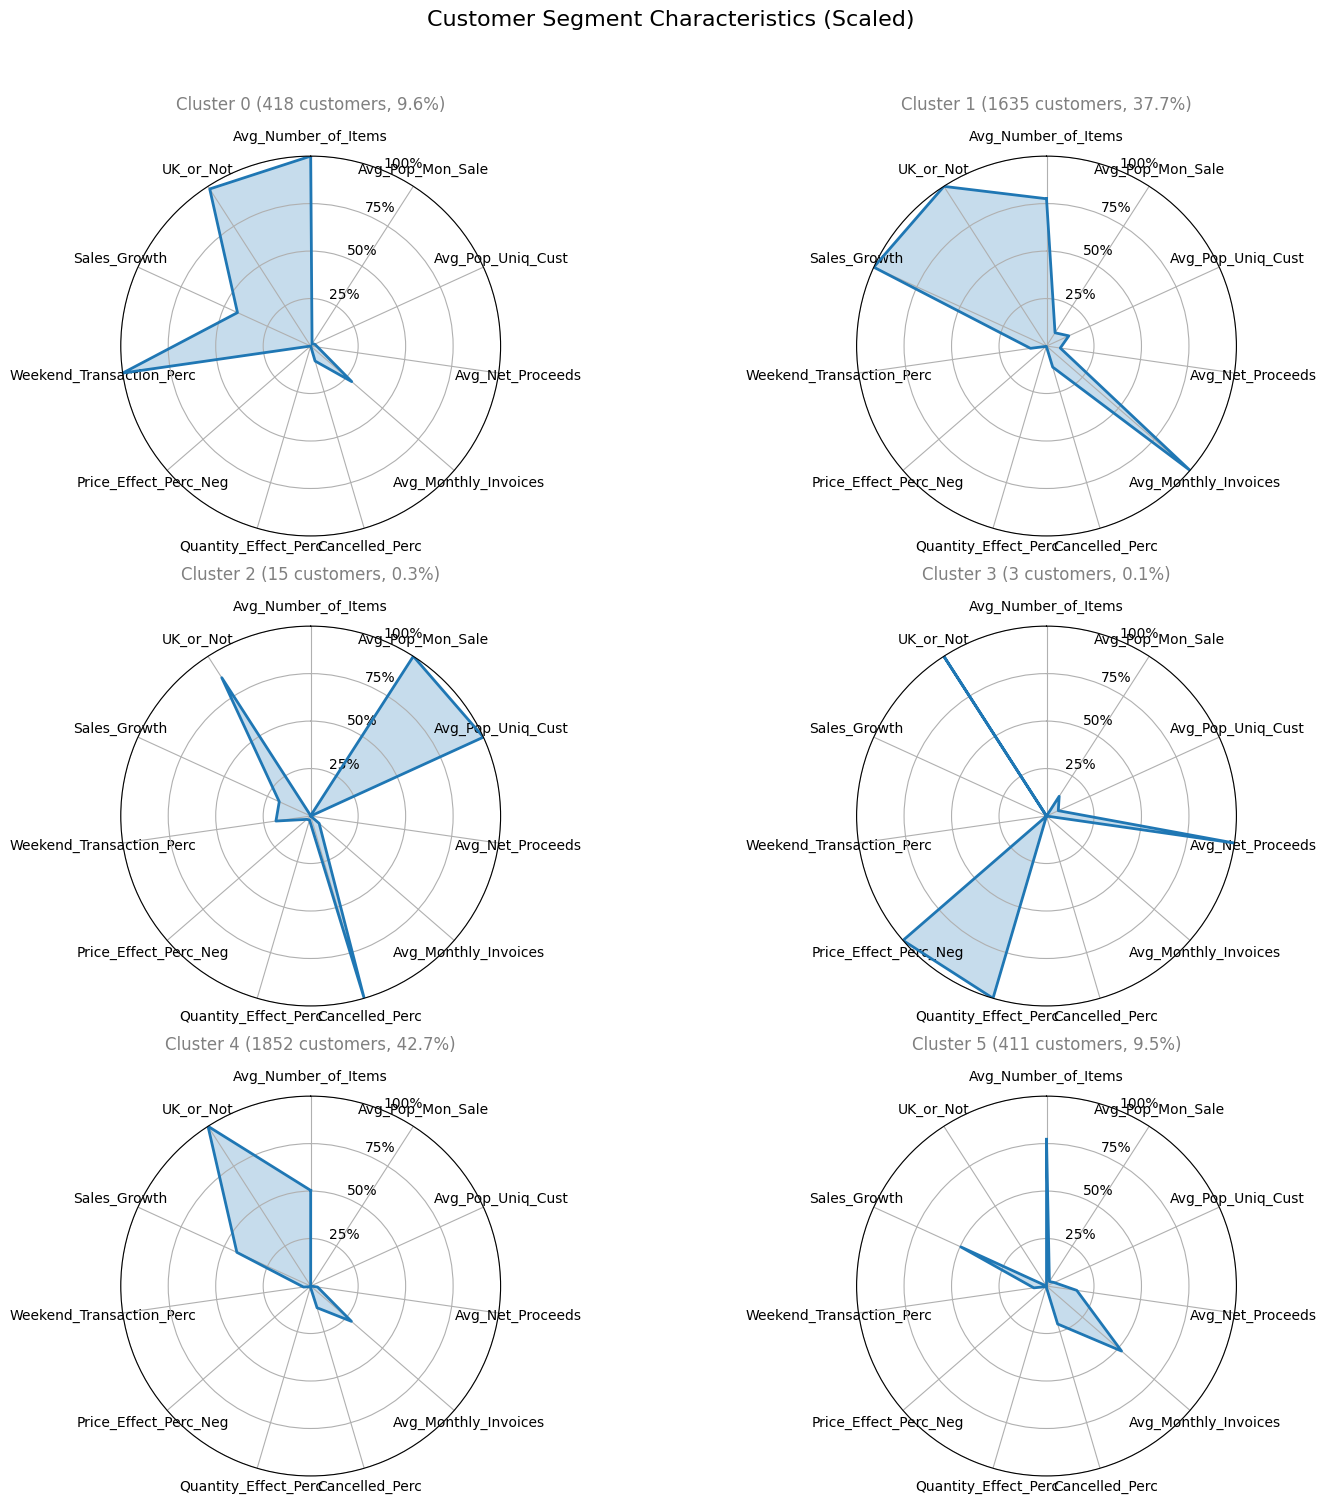

In [162]:
import numpy as np
import matplotlib.pyplot as plt

# Get the number of features and the features to plot
categories = list(radial_data_transposed.index) # Features are now the index after transposition
N = len(categories)

# Calculate angle for each feature
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Complete the circle

# Create a figure with a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(15, 15), subplot_kw=dict(polar=True))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot data for each cluster on a separate subplot
for i, cluster_label in enumerate(radial_data_transposed.columns): # Iterate over columns (clusters)
    values = radial_data_transposed[cluster_label].values.flatten().tolist() # Get values for the current cluster
    values += values[:1] # Complete the circle

    ax = axes[i]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%", "50%", "75%", "100%"])
    ax.set_ylim(0, 1)

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_label}')
    ax.fill(angles, values, alpha=0.25)

    # Add number of customers and percentage to the title
    count = cluster_counts[cluster_label]
    percentage = cluster_percentages[cluster_label]
    ax.set_title(f'Cluster {cluster_label} ({count} customers, {percentage:.1f}%)', size=12, color='grey', y=1.1)

# Remove any unused subplots (if the number of clusters is less than the number of subplots)
for j in range(len(radial_data_transposed.columns), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent titles overlapping
plt.suptitle('Customer Segment Characteristics (Scaled)', size=16, color='black', y=1.0) # Add a main title
plt.show()

# References

1. https://en.wikipedia.org/wiki/RFM_(market_research)
2. https://www.walmartworld.com/content/walmart-world/en_us/articles/2023/10/we-celebrate-25-years-of-neighborhood-markets.html
3. https://www.costco.com/f/-/company-information
4. https://www.ebsco.com/research-starters/business-and-management/home-depot
5. https://towardsdatascience.com/k-means-clustering-an-introductory-guide-and-practical-application-dce70bfa4249/
6. https://www.kdnuggets.com/2023/05/clustering-scikitlearn-tutorial-unsupervised-learning.html
7. https://medium.com/@carla.zarazir/unraveling-the-power-of-k-means-clustering-54404573cab6